In [22]:
# IMPORTS
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('classic')

In [23]:
# --- FUNCTIONS --- #
def convert_comma_to_dot(s):
    return float(s.replace(',','.'))


def norm_partial_pressure(data):
    return data/np.sum(data)


def moving_average(data, n):
    # Pad the data to handle edges
    padded_data = np.pad(data, (n, n), mode='edge')
    smoothed_data = np.zeros_like(data, dtype=float)

    for i in range(len(data)):
        # Calculate the average over the window
        window = padded_data[i:i + 2 * n + 1]
        smoothed_data[i] = np.mean(window)

    return smoothed_data


In [51]:
#--- DATA ---#
bg = np.loadtxt('../resources/data/FP10_qmf260114_003_bg_sp10_em-10_p54e-6.txt', delimiter='\t', converters={0: convert_comma_to_dot, 1: convert_comma_to_dot}).T
bg[0] = bg[0]/max(bg[0])
bg[1] = bg[1]*10


ar = np.loadtxt('../resources/data/FP10_qmf260114_004_ar_sp10_em-10_p13e-5.txt', delimiter='\t', converters={0: convert_comma_to_dot, 1: convert_comma_to_dot}).T
ar[0] = ar[0]/max(ar[0])
ar[1] = ar[1]*10


ac = np.loadtxt('../resources/data/FP10_qmf260114_007_ac_sp10_em-11_p14e-5.txt', delimiter='\t', converters={0: convert_comma_to_dot, 1: convert_comma_to_dot}).T
ac[0] = ac[0]/max(ac[0])
ac[1] = ac[1]*10

eth = np.loadtxt('../resources/data/FP10_qmf260114_009_eth_sp10_em-11_p16e-5.txt', delimiter='\t', converters={0: convert_comma_to_dot, 1: convert_comma_to_dot}).T
eth[0] = eth[0]/max(eth[0])
eth[1] = eth[1]*10

air = np.loadtxt('../resources/data/FP10_qmf260114_011_air_sp10_em-10_p15e-5.txt', delimiter='\t', converters={0: convert_comma_to_dot, 1: convert_comma_to_dot}).T
air[0] = air[0]/max(air[0])
air[1] = air[1]*10




In [30]:
print(moving_average(bg[1],2))

[9.881394 9.882046 9.881394 ... 9.874872 9.874872 9.870958]


In [ ]:
a = 10 # Moving average parameter
b = 1
# Cutting the plot parameters (to help with figuring out how to slice to get maxima for the peaks)
c = 20#800#650#530#450
d = 2700



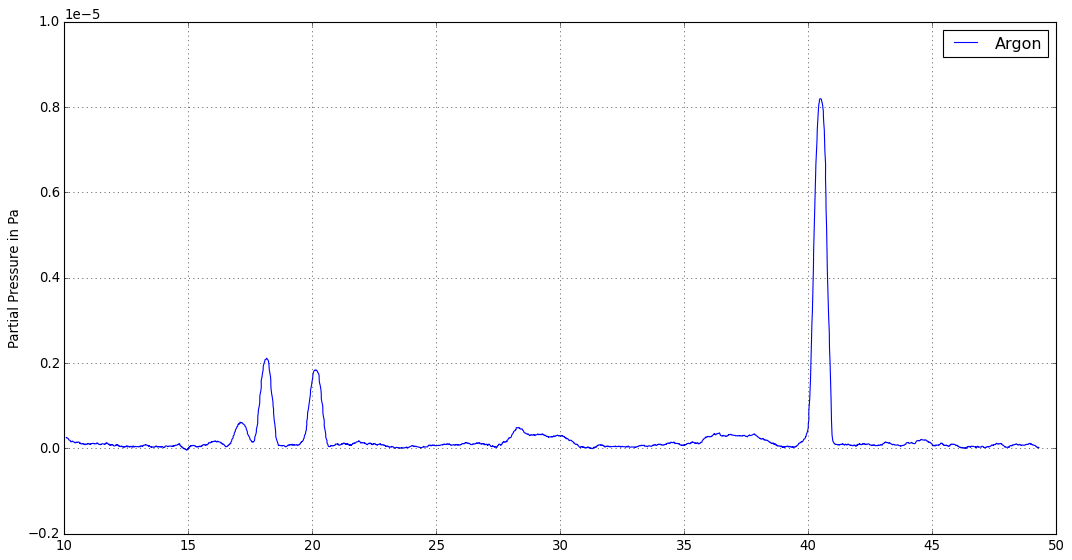

In [ ]:
#--- PLOT ---#
plt.figure(figsize=(16,8), dpi=80,facecolor='white', rasterized=True)


# PLOT ARGON
ar_x = ar[1]
ar_y = moving_average(ar[0],a) # smoothing data
ar_y = ar_y /(max(ar_y)+max(ar_y[650:800])+max(ar_y[450:530])+max(ar_y[530:650]))-min(ar_y) # deviding by the sum of the peaks, to normalize
ar_y = ar_y * 1.33e-5 # multiplying be absolute pressure to get estimate of partial pressure

# BACKGROUND
bg_x = bg[1]
bg_y = moving_average(bg[0],a)
bg_y = bg_y*max(ar_y[:650])/max(bg_y)-sum(bg_y[1000:2733]*max(ar_y[:650]))/1733

# ACETONE

ac_x = ac[1]
ac_y = moving_average(ac[0],a)
ac_y = ac_y/(max(ac_y))-min(ac_y)

# ETHANOL

eth_x = eth[1]
eth_y = moving_average(eth[0],a)
eth_y = eth_y/max(eth_y)-min(eth_y)
# AIR

air_x = air[1]
air_y = moving_average(air[0],a)
air_y = air_y/max(air_y)-min(air_y)



plt.plot(ar_x[c:d],ar_y[c:d], label='Argon')
#plt.plot(bg_x[c:d],bg_y[c:d], label='bg')

#plt.plot(ar_x[c:d],ar_y[c:d]-bg_y[c+9:d+9], label='argon – background')
#plt.plot(ac_x[c:d],ac_y[c:d], label='acetone')
#plt.plot(eth_x[c:d],eth_y[c:d], label='Ethanol')
#plt.plot(air_x[c:d],air_y[c:d], label='air')

plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.ylabel('Partial Pressure in Pa')
plt.grid()
plt.legend()